# Diffraction from Gaussian Beams: Projected Atomic Potential

This notebook demonstrates Gaussian-beam diffraction from a projected atomic potential using a simple square lattice of Si atoms.

The key idea:
1. A projected atomic potential produces a spatially varying phase shift across the beam.
2. The phase gradient deflects the Gaussian beamlets and the lattice periodicity sets the reciprocal-space peak spacing.
3. A lens maps diffraction angles to positions in the back focal plane.
4. The coherent sum of all beamlets produces Bragg spots at reciprocal-lattice positions.

### Convention note

In TemGymCore, `phase_shift(xy)` returns the action coefficient (optical path length in metres),
not the raw phase in radians. The actual phase is $k \times$ `phase_shift`. For `InterpolatedSample2D`,
`phase_shift = angle(T)`, so the input complex transmission must encode the action coefficient:
$$T(x,y) = |A(x,y)| \exp\!\bigl(i\, \phi(x,y) / k\bigr)$$
where $\phi$ is the physical phase in radians.

In [43]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.3"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import abtem
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms

from temgym_core.components import Detector, Lens, Plane, sample_interpolant
from temgym_core.constants import energy2wavelength, interaction_constant_CE
from temgym_core.evaluate import evaluate_gaussians_cuda_gpu_kernel_wrapper_opt as evaluate_beams
from temgym_core.plotting import plot_model, PlotParams
from temgym_core.run import run_to_end_vmapped
from temgym_core.source import square_input_wave

%matplotlib widget

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)
print("abTEM version:", abtem.__version__)
print("XLA_PYTHON_CLIENT_MEM_FRACTION:", os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"])
print("XLA_PYTHON_CLIENT_PREALLOCATE:", os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"])

JAX backend: gpu
abTEM version: 1.0.9
XLA_PYTHON_CLIENT_MEM_FRACTION: 0.3
XLA_PYTHON_CLIENT_PREALLOCATE: false


## Setup

In [35]:
voltage = 200e3  # 200 kV electron beam
wavelength = float(energy2wavelength(voltage))
k = 2 * np.pi / wavelength
f = 2.3e-3  # 2.3 mm focal length
n_det = 256

print(f"Electron wavelength: {wavelength * 1e12:.2f} pm")
print(f"k = {k:.3e} 1/m")

Electron wavelength: 2.51 pm
k = 2.505e+12 1/m


## 1. Build the Projected Atomic Potential

We use abTEM to generate the thin projected potential of a simple square lattice of Si atoms on a regular grid, then convert that projected phase into the action coefficient used by the Gaussian-beam sample component.

In [36]:
# Build a 2D square lattice of Si atoms for abTEM
lattice_constant = 5.43e-10  # Si lattice constant in metres
lattice_constant_A = lattice_constant * 1e10
n_cells = 10  # repeat units in each direction
sample_width = n_cells * lattice_constant
sample_width_A = sample_width * 1e10
sample_thickness_A = lattice_constant_A

# Projected potential resolution
n_pot = 256

# Atom positions inside the abTEM box, in Angstrom
atom_xs_A = (np.arange(n_cells) + 0.5) * lattice_constant_A
atom_ys_A = atom_xs_A.copy()
atom_xs, atom_ys = np.meshgrid(atom_xs_A, atom_ys_A, indexing="xy")
atom_positions_A = np.column_stack(
    [atom_xs.ravel(), atom_ys.ravel(), np.full(atom_xs.size, sample_thickness_A / 2)]
)

atoms = Atoms(
    symbols=["Si"] * atom_positions_A.shape[0],
    positions=atom_positions_A,
    cell=[sample_width_A, sample_width_A, sample_thickness_A],
    pbc=False,
)

print(f"Lattice: {n_cells}x{n_cells} cells, a = {lattice_constant_A:.2f} A")
print(f"Sample width: {sample_width*1e9:.2f} nm")
print(f"abTEM atoms: {len(atoms)}")

Lattice: 10x10 cells, a = 5.43 A
Sample width: 5.43 nm
abTEM atoms: 100


tasks:   0%|          | 0/2 [00:00<?, ?it/s]

abTEM projected grid: 256x256
Grid spacing: 21.2 pm
Max projected potential: 541.424 V*A
Max phase shift: 0.395 rad
Max action coeff (phase/k): 1.58e-13 m


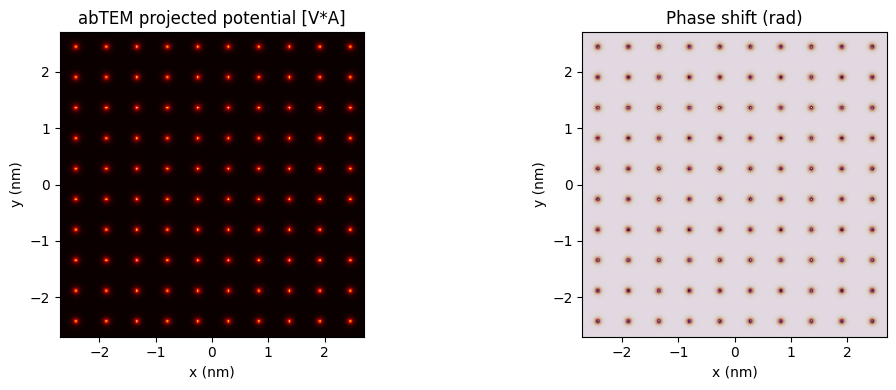

In [37]:
# Compute the projected potential with abTEM
potential = abtem.Potential(
    atoms,
    gpts=(n_pot, n_pot),
    parametrization="lobato",
    projection="infinite",
    periodic=False,
    box=(sample_width_A, sample_width_A, sample_thickness_A),
)
proj = potential.project().compute()
V_proj_angstrom = np.asarray(proj.array)

sy_A, sx_A = map(float, proj.sampling)
ny, nx = V_proj_angstrom.shape
y_pot = (np.arange(ny) - (ny - 1) / 2) * sy_A * 1e-10
x_pot = (np.arange(nx) - (nx - 1) / 2) * sx_A * 1e-10
dx_pot = float(x_pot[1] - x_pot[0])

sigma = float(interaction_constant_CE(voltage))
V_proj = V_proj_angstrom * 1e-10
phase_atom = -sigma * V_proj
action_atom = phase_atom / k
transmission_atom = np.exp(1j * action_atom)

sample_atom = sample_interpolant(
    sample=transmission_atom,
    x_coords=x_pot,
    y_coords=y_pot,
    z=0.0,
    method="cubic",
    extrap=1.0,
)

print(f"abTEM projected grid: {nx}x{ny}")
print(f"Grid spacing: {dx_pot*1e12:.1f} pm")
print(f"Max projected potential: {np.abs(V_proj_angstrom).max():.3f} V*A")
print(f"Max phase shift: {np.abs(phase_atom).max():.3f} rad")
print(f"Max action coeff (phase/k): {np.abs(action_atom).max():.2e} m")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ext_nm = [x_pot[0] * 1e9, x_pot[-1] * 1e9, y_pot[0] * 1e9, y_pot[-1] * 1e9]

axes[0].imshow(V_proj_angstrom, extent=ext_nm, origin="lower", cmap="hot")
axes[0].set_title("abTEM projected potential [V*A]")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")

axes[1].imshow(phase_atom, extent=ext_nm, origin="lower", cmap="twilight")
axes[1].set_title("Phase shift (rad)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
plt.tight_layout()

## 2. Propagate Through the Atomic Sample

In [38]:
# Gaussian waist = 5x wavelength for finer atomic-column resolution,
# with overlap_factor = 1.0 to keep beam count reasonable.
waist_atom = 5 * wavelength
min_waist = 3 * wavelength

assert waist_atom >= min_waist, (
    f"Waist {waist_atom:.2e} m is below 3*lambda = {min_waist:.2e} m."
)

print(f"Potential grid spacing dx_pot: {dx_pot*1e12:.1f} pm")
print(f"Gaussian waist: {waist_atom*1e12:.1f} pm")
print(f"Waist / wavelength: {waist_atom / wavelength:.1f}x  (must be >= 3)")

rays_in_atom = square_input_wave(
    aperture_length=sample_width,
    waist=waist_atom,
    voltage=voltage,
    overlap_factor=1.0,
    z0=0.0,
)
n_beams_atom = int(np.asarray(rays_in_atom.x).size)
print(f"Number of Gaussian beams: {n_beams_atom}")

# Through sample
rays_after_atom = run_to_end_vmapped(rays_in_atom, (sample_atom,))

# Through lens to BFP
lens_atom = Lens(z=f, focal_length=f)
bfp_plane_atom = Plane(z=2 * f)
rays_bfp_atom = run_to_end_vmapped(rays_after_atom, (lens_atom, bfp_plane_atom))

print(f"Angle range after sample: [{float(rays_after_atom.dx.min()):.2e}, {float(rays_after_atom.dx.max()):.2e}] rad")

Potential grid spacing dx_pot: 21.2 pm
Gaussian waist: 12.5 pm
Waist / wavelength: 5.0x  (must be >= 3)
Number of Gaussian beams: 188356
Angle range after sample: [-5.82e-03, 5.82e-03] rad


In [39]:
# Expected Bragg spots: x_hk = (lambda*f/a) * h
bragg_spacing_atom = wavelength * f / lattice_constant
print(f"Expected Bragg spot spacing: {bragg_spacing_atom*1e6:.3f} um")

# Detector at BFP
bfp_width_atom = 6 * bragg_spacing_atom
pixel_atom = 2 * bfp_width_atom / n_det

detector_bfp_atom = Detector(
    z=2 * f,
    pixel_size=(pixel_atom, pixel_atom),
    shape=(n_det, n_det),
)

field_bfp_atom = evaluate_beams(rays_bfp_atom, detector_bfp_atom)
intensity_bfp_atom = jnp.abs(field_bfp_atom) ** 2

Expected Bragg spot spacing: 10.623 um


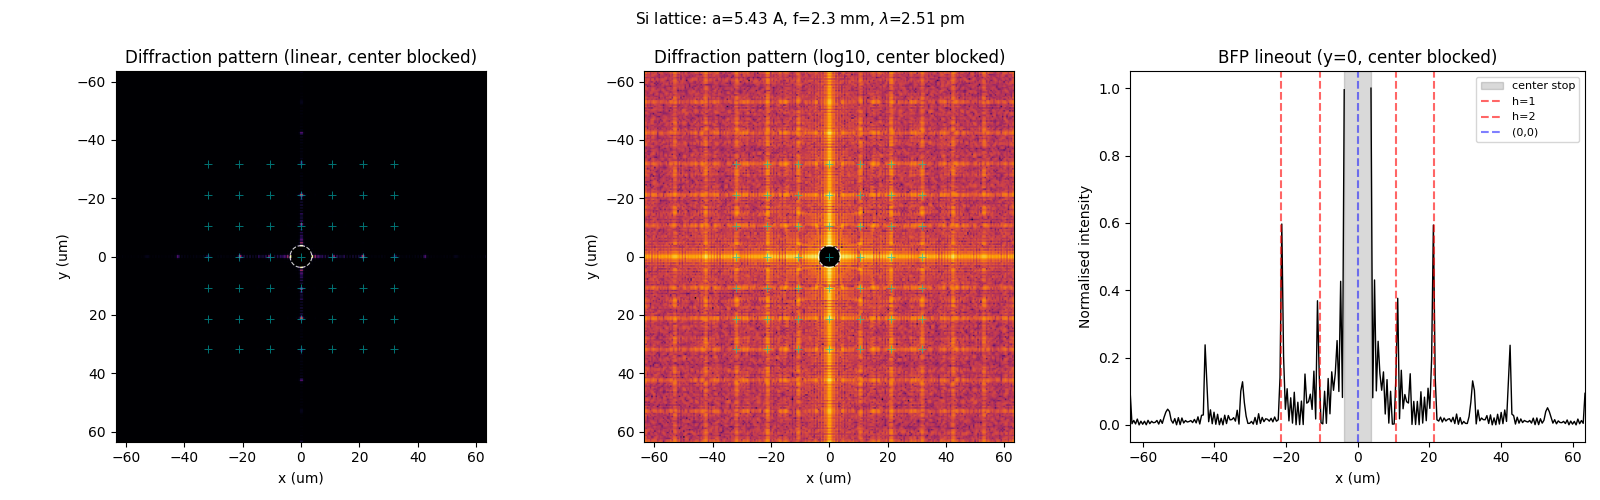

In [46]:
# Plot diffraction pattern (linear + log) and 1D lineout
ext_atom = detector_bfp_atom.extent
ext_atom_um = [e * 1e6 for e in ext_atom]
I_atom = np.asarray(intensity_bfp_atom)
I_atom_norm = I_atom / I_atom.max()
eps = 1e-16

# Display-only center stop to reveal weaker diffracted beams.
x_um_atom = np.linspace(ext_atom_um[0], ext_atom_um[1], n_det)
y_um_atom = np.linspace(ext_atom_um[2], ext_atom_um[3], n_det)
X_um, Y_um = np.meshgrid(x_um_atom, y_um_atom)
center_stop_radius_um = 0.35 * bragg_spacing_atom * 1e6
center_stop_mask = np.sqrt(X_um**2 + Y_um**2) <= center_stop_radius_um

I_atom_masked = I_atom_norm.copy()
I_atom_masked[center_stop_mask] = np.nan
I_atom_log_masked = np.log10(I_atom_norm + eps)
I_atom_log_masked[center_stop_mask] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 2D pattern (unlogged / linear) with blocked direct beam
ax = axes[0]
im0 = ax.imshow(
    I_atom_masked,
    extent=ext_atom_um,
    origin="lower",
    cmap="inferno",
)
im0.cmap.set_bad(color="black")
for h in range(-3, 4):
    for kk in range(-3, 4):
        ax.plot(
            h * bragg_spacing_atom * 1e6,
            kk * bragg_spacing_atom * 1e6,
            "c+",
            markersize=6,
            mew=0.7,
            alpha=0.6,
        )
circle0 = plt.Circle((0.0, 0.0), center_stop_radius_um, color="white", fill=False, ls="--", lw=0.8, alpha=0.8)
ax.add_patch(circle0)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("Diffraction pattern (linear, center blocked)")

# 2D pattern (logged) with blocked direct beam
ax = axes[1]
im1 = ax.imshow(
    I_atom_log_masked,
    extent=ext_atom_um,
    origin="lower",
    cmap="inferno",
)
im1.cmap.set_bad(color="black")
for h in range(-3, 4):
    for kk in range(-3, 4):
        ax.plot(
            h * bragg_spacing_atom * 1e6,
            kk * bragg_spacing_atom * 1e6,
            "c+",
            markersize=6,
            mew=0.7,
            alpha=0.6,
        )
circle1 = plt.Circle((0.0, 0.0), center_stop_radius_um, color="white", fill=False, ls="--", lw=0.8, alpha=0.8)
ax.add_patch(circle1)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("Diffraction pattern (log10, center blocked)")

# 1D lineout with center blocked
ax = axes[2]
centre_atom = n_det // 2
lineout_atom = I_atom[centre_atom, :]
lineout_center_mask = np.abs(x_um_atom) <= center_stop_radius_um

lineout_atom_masked = lineout_atom.astype(float).copy()
lineout_atom_masked[lineout_center_mask] = np.nan
lineout_scale = np.nanmax(lineout_atom_masked)
lineout_atom_masked /= lineout_scale

ax.plot(x_um_atom, lineout_atom_masked, "k-", lw=1)
ax.axvspan(-center_stop_radius_um, center_stop_radius_um, color="black", alpha=0.15, label="center stop")
for h in [-2, -1, 1, 2]:
    ax.axvline(
        h * bragg_spacing_atom * 1e6,
        color="red",
        ls="--",
        alpha=0.6,
        label=f"h={h}" if h > 0 else None,
    )
ax.axvline(0, color="blue", ls="--", alpha=0.5, label="(0,0)")
ax.set_xlabel("x (um)")
ax.set_ylabel("Normalised intensity")
ax.set_title("BFP lineout (y=0, center blocked)")
ax.legend(fontsize=8)
ax.set_xlim(ext_atom_um[0], ext_atom_um[1])

fig.suptitle(
    f"Si lattice: a={lattice_constant*1e10:.2f} A, "
    f"f={f*1e3:.1f} mm, $\\lambda$={wavelength*1e12:.2f} pm",
    fontsize=11,
)
plt.tight_layout()

## 3. Ray Diagram

Plotting 15 representative beams
Initial beams: 188356
Retained fraction: 0.0080%
Beams per order: {-2: 3, -1: 3, 0: 3, 1: 3, 2: 3}


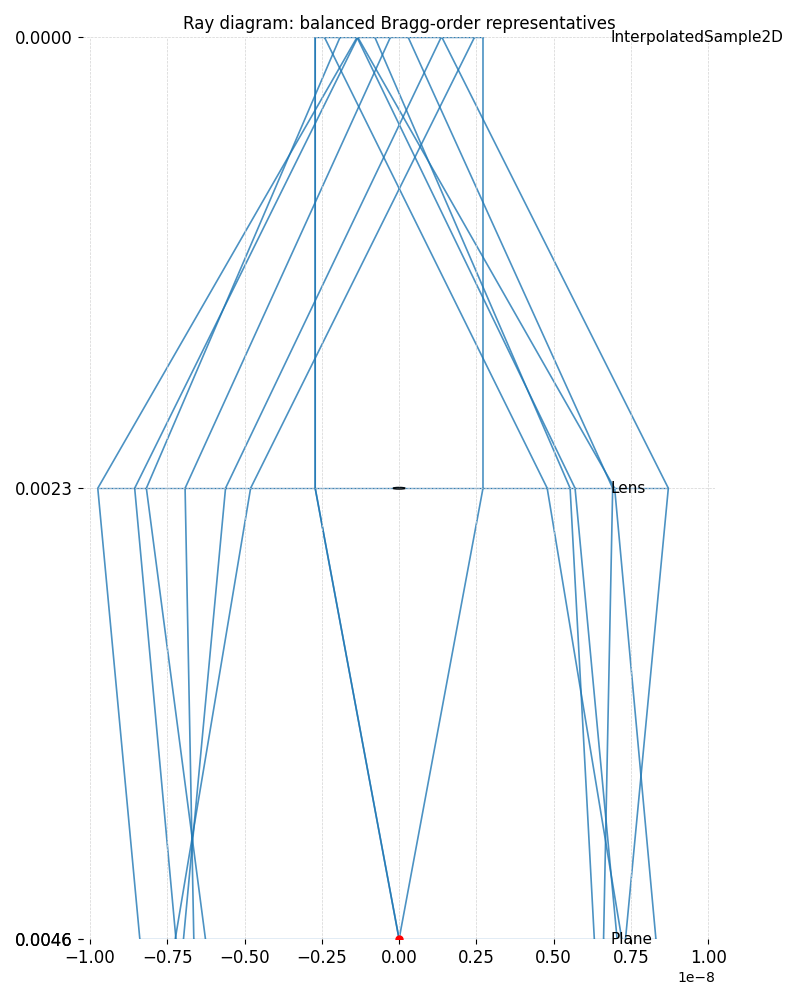

In [51]:
# Build a cleaner 1D ray diagram with balanced representatives per Bragg order.
y_after = np.asarray(rays_after_atom.y)
x_bfp = np.asarray(rays_bfp_atom.x)
y_bfp = np.asarray(rays_bfp_atom.y)
dx_after = np.asarray(rays_after_atom.dx)

# Base geometric filters.
mask_slice = np.abs(y_after) < waist_atom
mask_bfp_y = np.abs(y_bfp) < 0.25 * bragg_spacing_atom
dx_limit = np.quantile(np.abs(dx_after), 0.98)
mask_angle = np.abs(dx_after) <= dx_limit
base_idx = np.where(mask_slice & mask_bfp_y & mask_angle)[0]

if len(base_idx) == 0:
    raise RuntimeError("No rays left after base filtering.")

orders = np.array([-2, -1, 0, 1, 2], dtype=int)
n_per_order = 3
selected = []
order_counts = {}

for h in orders:
    xh = h * bragg_spacing_atom

    # Keep order sign-consistent candidates to avoid central-only selection.
    if h < 0:
        cand = base_idx[x_bfp[base_idx] < 0]
    elif h > 0:
        cand = base_idx[x_bfp[base_idx] > 0]
    else:
        cand = base_idx[np.abs(x_bfp[base_idx]) <= 0.25 * bragg_spacing_atom]

    if len(cand) == 0:
        order_counts[int(h)] = 0
        continue

    dist = np.abs(x_bfp[cand] - xh)
    cand_sorted = cand[np.argsort(dist)]

    # Avoid reusing the same ray in multiple order bins.
    cand_sorted = np.array([i for i in cand_sorted if i not in selected], dtype=int)
    if len(cand_sorted) == 0:
        order_counts[int(h)] = 0
        continue

    take = min(n_per_order, len(cand_sorted))
    chosen = cand_sorted[:take]
    selected.extend(chosen.tolist())
    order_counts[int(h)] = int(take)

idx_atom = np.array(sorted(set(selected)), dtype=int)
if len(idx_atom) == 0:
    raise RuntimeError("No rays selected for plotting; relax filters.")

rays_1d_atom = jax.tree.map(lambda a: a[idx_atom], rays_after_atom)
print(f"Plotting {len(idx_atom)} representative beams")
print(f"Initial beams: {len(y_after)}")
print(f"Retained fraction: {100.0 * len(idx_atom) / len(y_after):.4f}%")
print("Beams per order:", order_counts)

components_atom_plot = [sample_atom, lens_atom, bfp_plane_atom]

fig, ax = plot_model(
    components_atom_plot,
    rays=rays_1d_atom,
    plot_params=PlotParams(figsize=(8, 10)),
    band_mode="lines",
    ray_coordinate="x",
)

for h in [-2, -1, 0, 1, 2]:
    xh = h * bragg_spacing_atom
    ax.plot(xh, 2 * f, "ro", markersize=5, zorder=5)

ax.set_title("Ray diagram: balanced Bragg-order representatives")
plt.tight_layout()

### Summary

This notebook isolates the projected atomic-potential example from the original Bragg notebook so the lattice diffraction workflow can be developed independently.